<a href="https://colab.research.google.com/github/aditi0104/PortfolioProjects/blob/main/Basics_of_Reinforcement_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Part 1

In [ ]:
!pip install gym

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gym
from gym import spaces

""


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

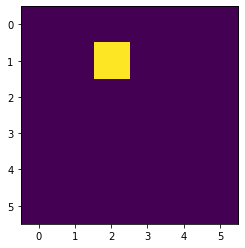

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import widgets
import time

output_grid = widgets.Grid(1, 1)
for _ in range(5):
  grid = np.zeros((6, 6))
  grid[np.random.randint(3), np.random.randint(3)] = 1
  with output_grid.output_to(0, 0):
    output_grid.clear_cell()
    plt.imshow(grid)
  time.sleep(1)

In [ ]:
class GridEnvironment(gym.Env):
    metadata = { 'render.modes': [] }

    def __init__(self):
        self.observation_space = spaces.Discrete(36)
        self.action_space = ['left','right','up','down']
        #self.action_space = spaces.Discrete(4)
        self.max_timesteps = 20

    def reset(self):
        self.timestep = 0
        self.agent_pos = [0, 0]
        self.goal_pos = [5, 5]
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()
        return observation

    def step(self, action):
        self.state = np.random.choice(self.observation_space.n)
        reward = 0
        if (self.agent_pos[0] > -1 and self.agent_pos[0] <= 5) and (self.agent_pos[1] > -1 and self.agent_pos[1] <= 5):
            if (self.agent_pos[0] == 0 and action == 'left') or (self.agent_pos[1] == 5 and action == 'down') or (self.agent_pos[0] == 5 and action == 'right') or (self.agent_pos[1] == 0 and action == 'up'):
                self.agent_pos = [0, 0]
                reward = 0
                print('Resetted')
                # if (self.agent_pos[0] == 5 and action == 'right') or (self.agent_pos[1] == 0 and action == 'up'):
                #     self.agent_pos = [0, 0]
                #     reward = 0
                #     print('Resetted')
        # self.state = np.random.choice(self.observation_space.n)
            elif action == 'left':
                self.agent_pos[0] -= 1
            elif action == 'right':
                self.agent_pos[0] += 1
            elif action == 'up':
                self.agent_pos[1] -= 1
            elif action == 'down':
                self.agent_pos[1] += 1

        self.agent_pos = np.clip(self.agent_pos, 0, 5)
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5
        # print(self.state.shape[0])
        observation = self.state.flatten()

        # if (self.agent_pos == self.goal_pos).all():
        #   reward = 1

        if self.agent_pos[0] == 4 and self.agent_pos[1] == 2:
            reward = 20
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 0:
            reward = -7
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 3:
            reward = -5
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 5:
            reward = 10
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 5:
            reward = 50

        self.timestep += 1
        done = True if self.timestep == self.max_timesteps else False
        info = {}

        return observation, reward, done, action,self.agent_pos, info

    def render(self):
        plt.imshow(self.state)

In [ ]:
class RandomAgent:
  def __init__(self, env):
    self.env = env
    self.observation_space = env.observation_space
    self.action_space = env.action_space

  def step(self, observation):
    return np.random.choice(self.action_space)

""


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.5] 0 True down [2 2] {}


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

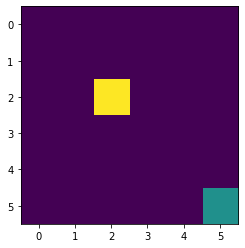

<IPython.core.display.Javascript object>

In [ ]:
env = GridEnvironment()
agent = RandomAgent(env)

obs = env.reset()
done = False

output_grid = widgets.Grid(1, 1)
with output_grid.output_to(0, 0):
  env.render()


while not done:
  action = agent.step(obs)
  obs, reward, done, action, agent_pos, info = env.step(action)
  print(obs, reward, done, action,agent_pos, info)
  with output_grid.output_to(0, 0):
    output_grid.clear_cell()
    env.render()
  time.sleep(1)

Part II: Solve your environment using a tabular
method – SARSA

In [ ]:
import gym
import numpy as np
import time, pickle, os
import matplotlib.pyplot as plt
from gym import spaces

In [ ]:
class GridEnvironment_SARSA(gym.Env):
    metadata = { 'render.modes': [] }

    def __init__(self):
        self.observation_space = spaces.Discrete(36)
        self.action_space = spaces.Discrete(4)
        self.max_timesteps = 216
        self.q_table = {}
        for i in range(6):
          for j in range(6):
            self.q_table[(i,j)] = np.zeros(4)

    def reset(self):
        self.timestep = 0
        self.agent_pos = [0, 0]
        self.goal_pos = [5, 5]
        self.state = np.zeros((6,6))

        if self.agent_pos[0] == 0 and self.agent_pos[1] == 0:
            reward = 0
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 1:
            reward = 1
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 2:
            reward = 2
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 3:
            reward = 3
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 4:
            reward = 4
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 5:
            reward = 5
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 0:
            reward = 6
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 1:
            reward = 7
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 2:
            reward = 8
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 3:
            reward = 9
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 4:
            reward = 1
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 1:
            reward = 4
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 3:
            reward = 6
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 4:
            reward = 1
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 1:
            reward = 4
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 3:
            reward = 6
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 4:
            reward = 7
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 0:
            reward = 1
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 1:
            reward = 3
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 3:
            reward = 4
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 4:
            reward = 4
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 1:
            reward = 6
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 2:
            reward = 3
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 3:
            reward = 48
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 4:
            reward = 49
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 5:
            reward = 50

        # self.reward = np.array([0,1,2,3,1,2,3,4,5,3,4,2,2,5,7,3,5,3,4,2,3,4,5,47,8,5,3,48,4,6,7,2,45,6,49,50]).reshape(6,6) #updating rewards after collecting it on every position
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5
        observation_sarsa = self.state.flatten()
        return observation_sarsa

    def get_action(self, epsilon):
      n = np.random.random()
      if n > epsilon:
        action = (self.q_table[tuple(self.agent_pos)]).argmax()          #choosing best action
      else:
        action = np.random.choice([0,1,2,3])                              #choosing random action
      return action

    def step(self, action):
        self.state = np.random.choice(self.observation_space.n)
        reward = 0

        if action == 0:
            self.agent_pos[0] -= 1
        if action == 1:
            self.agent_pos[0] += 1
        if action == 2:
            self.agent_pos[1] -= 1
        if action == 3:
            self.agent_pos[1] += 1

        self.agent_pos = np.clip(self.agent_pos, 0, 5)
        self.state = np.zeros((6,6))
        self.state[tuple(self.agent_pos)] = 1
        self.state[tuple(self.goal_pos)] = 0.5
        observation = self.state.flatten()

        # reward = [0,1,2,3,1,2,3,4,5,3,4,2,2,5,7,3,5,3,4,2,3,4,5,47,8,5,3,48,4,6,7,2,45,6,49,50]
        # reward = np.array(reward).reshape(6,6)

        if self.agent_pos[0] == 0 and self.agent_pos[1] == 0:
            reward = 0
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 1:
            reward = 1
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 2:
            reward = 2
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 3:
            reward = 3
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 4:
            reward = 4
        if self.agent_pos[0] == 0 and self.agent_pos[1] == 5:
            reward = 5
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 0:
            reward = 6
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 1:
            reward = 7
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 2:
            reward = 8
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 3:
            reward = 9
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 4:
            reward = 1
        if self.agent_pos[0] == 1 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 1:
            reward = 4
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 3:
            reward = 6
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 4:
            reward = 1
        if self.agent_pos[0] == 2 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 1:
            reward = 4
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 3:
            reward = 6
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 4:
            reward = 7
        if self.agent_pos[0] == 3 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 0:
            reward = 1
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 1:
            reward = 3
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 2:
            reward = 5
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 3:
            reward = 4
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 4:
            reward = 4
        if self.agent_pos[0] == 4 and self.agent_pos[1] == 5:
            reward = 2
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 0:
            reward = 3
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 1:
            reward = 6
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 2:
            reward = 3
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 3:
            reward = 48
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 4:
            reward = 49
        if self.agent_pos[0] == 5 and self.agent_pos[1] == 5:
            reward = 50

        self.timestep += 1
        done = True if self.timestep >= self.max_timesteps or (self.agent_pos == self.goal_pos).all() else False
        info = {}

        return observation_sarsa, reward, done

    def update_qtable(self,agent_previous_pos,previous_action,agent_new_pos,new_action,reward):
        env_sarsa.q_table[tuple(agent_previous_pos)][previous_action] = env_sarsa.q_table[tuple(agent_previous_pos)][previous_action] + learning_rate * (reward + gamma * (env_sarsa.q_table[tuple(agent_new_pos)][new_action]) - env_sarsa.q_table[tuple(agent_previous_pos)][previous_action])


    def render(self):
        plt.imshow(self.state)



In [ ]:
env_sarsa = GridEnvironment_SARSA()

In [ ]:
observation_sarsa = env_sarsa.reset()
episode = 1000
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.87
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while True:
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

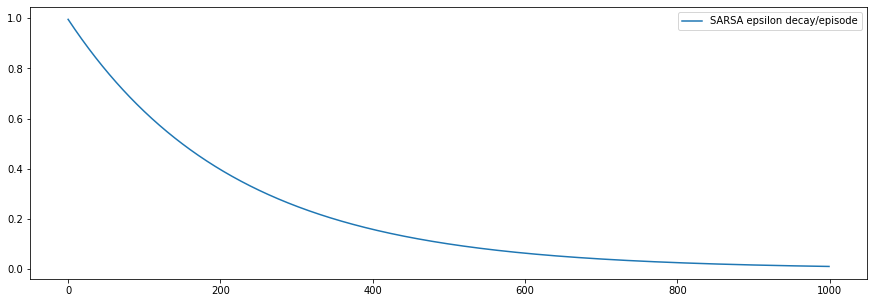

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

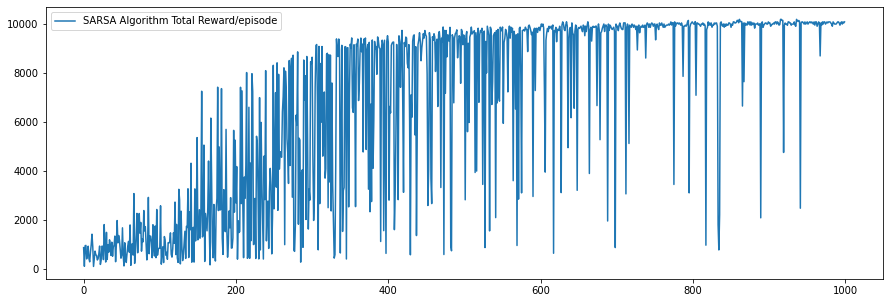

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
for i in range(6):
  for j in range(6):
    print(env_sarsa.q_table[(i,j)])

[ 89.46622511 163.37401073  65.75236029  70.17159504]
[ 42.81946347 138.70140915  44.42531904  40.10473838]
[ 31.33621118 114.53552683  28.57798751  29.41864286]
[28.90854111 45.41920776 28.54965632 23.16282516]
[20.27344565 21.01853381 28.44195375 17.37521847]
[17.07750654 12.92731718 23.340604   16.50639259]
[ 97.51852801  61.43020779  86.56224957 182.10264205]
[ 58.77977378  91.77603318  95.75482663 202.33535122]
[ 69.3024328  224.02695593 103.07266616  91.39063059]
[ 35.55320972  63.82006106 145.76993041  27.42308412]
[20.88163409 16.87325616 47.82621392 15.09982981]
[21.26164663  7.765259   19.06987926 10.26800501]
[101.6997915   14.79066147  24.65722883  35.80201409]
[ 50.07703784  60.35460571  29.92007528 176.75123511]
[ 94.87151241 252.09963863 105.8212265  133.22757226]
[ 45.57519573 215.45886678  42.41237398  22.60715123]
[26.00122672 31.33999182 59.36864269  8.41301672]
[14.07481284  7.5577947  11.12596735  6.74687013]
[29.3763484   6.15454203 15.18691972 14.4432748 ]
[ 42.1

In [ ]:
#Greedy value choosing for episodes as 10 Run your environment for at least 10 episodes, where the agent chooses only greedy actions from the learnt policy. Plot should include the total reward per episode
observation_sarsa = env_sarsa.reset()
episode = 20
df=(0.01) ** (1/episode)
epsilon = 0.01
learning_rate = 0.09
gamma = 0.90
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

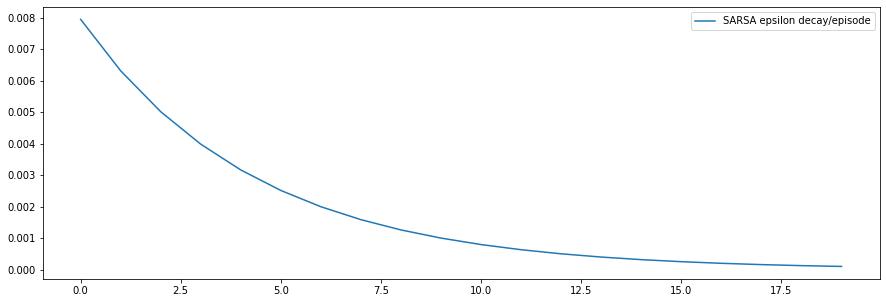

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

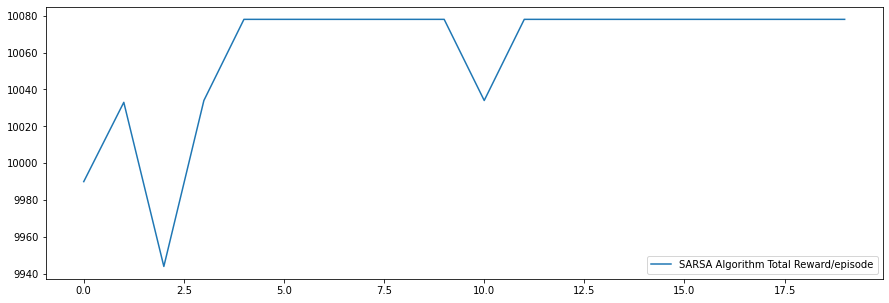

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

# Tuning Hyper Parameters

In [ ]:
#Tuning hyper parameter - discount factor value - 0.90
observation_sarsa = env_sarsa.reset()
episode = 1000
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.90
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

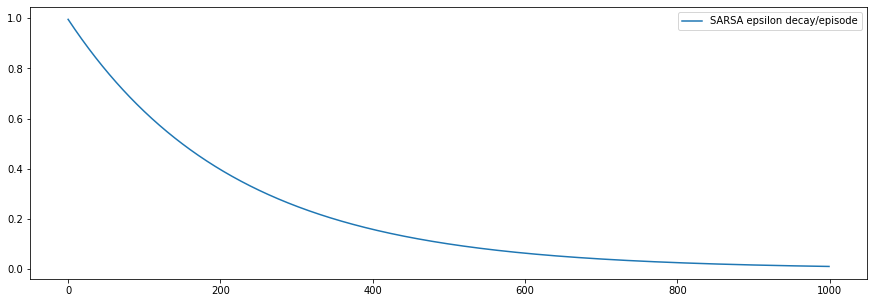

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

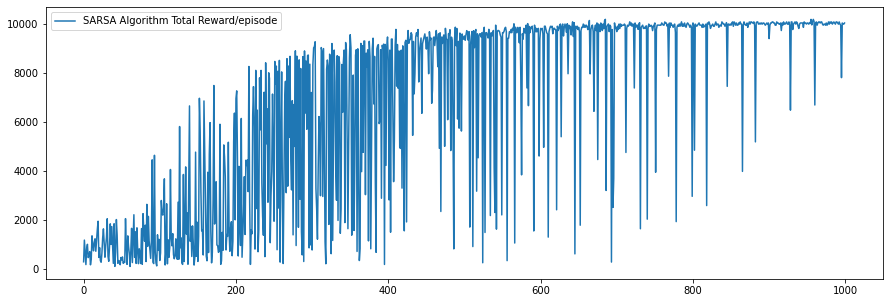

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
#Tuning hyper parameter - discount factor value - 0.65
observation_sarsa = env_sarsa.reset()
episode = 1000
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.65
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

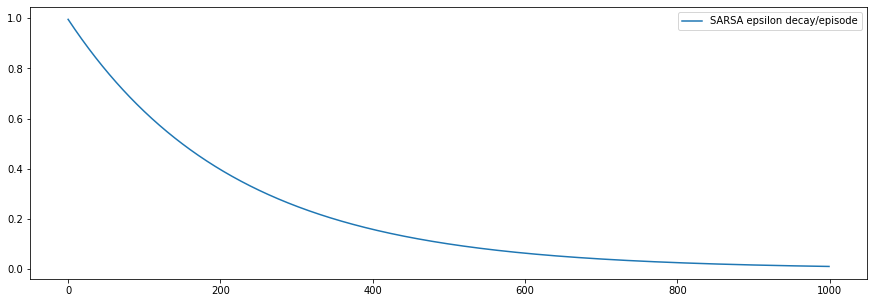

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

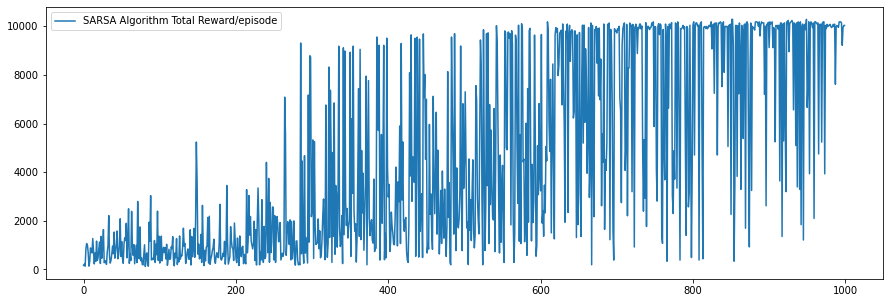

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
#Tuning hyper parameter - discount factor value - 0.79
observation_sarsa = env_sarsa.reset()
episode = 1000
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.79
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

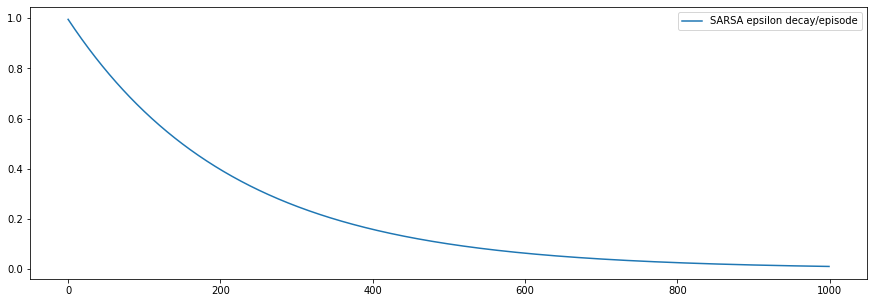

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

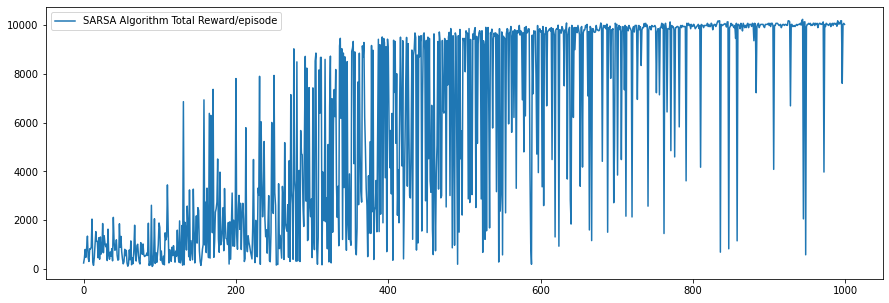

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
#Tuning hyper parameter - Episodes - 100
observation_sarsa = env_sarsa.reset()
episode = 100
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.90
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

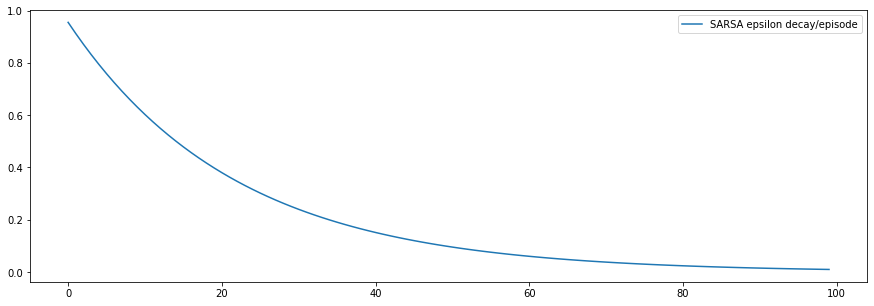

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

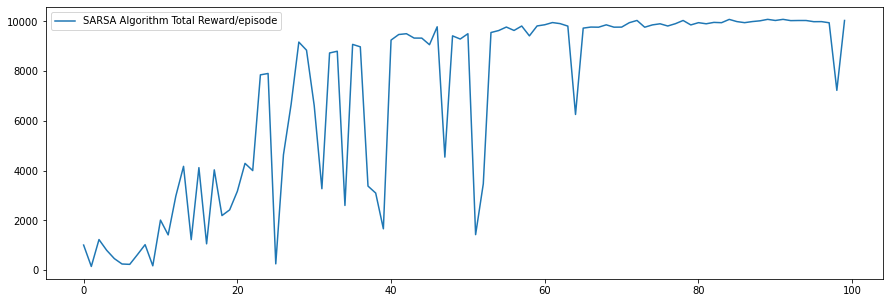

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
#Tuning hyper parameter - Episodes - 550
observation_sarsa = env_sarsa.reset()
episode = 550
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.90
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

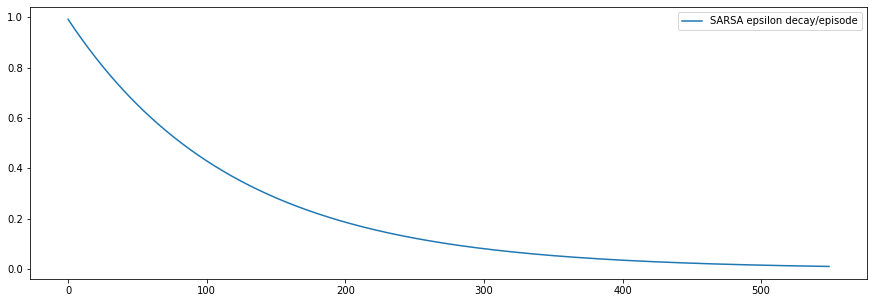

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

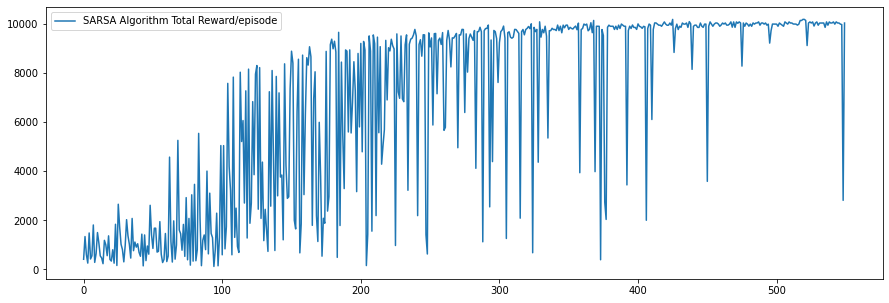

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

In [ ]:
#Tuning hyper parameter - Episodes - 890
observation_sarsa = env_sarsa.reset()
episode = 890
df=(0.01) ** (1/episode)
epsilon = 1
learning_rate = 0.09
gamma = 0.90
iteration_SARSA = []
reward_per_episode_SARSA = []
epsilon_decay_SARSA = []

In [ ]:
for i in range(episode):
  total_reward = 0
  epsilon_decay = 0
  k = 0
  obs_sarsa = env_sarsa.reset()
  previous_action = env_sarsa.get_action(epsilon)
  while(True):
    k += 1
    agent_previous_pos = env_sarsa.agent_pos.copy()
    observation_sarsa, reward, done = env_sarsa.step(previous_action)
    total_reward += reward
    new_action = env_sarsa.get_action(epsilon)
    agent_new_pos = env_sarsa.agent_pos
    env_sarsa.update_qtable(agent_previous_pos,previous_action,agent_new_pos,new_action,reward)
    previous_action = new_action
    if done:
      break
  epsilon = epsilon * df
  epsilon_decay_SARSA.append(epsilon)
  reward_per_episode_SARSA.append(total_reward)
  iteration_SARSA.append(k)

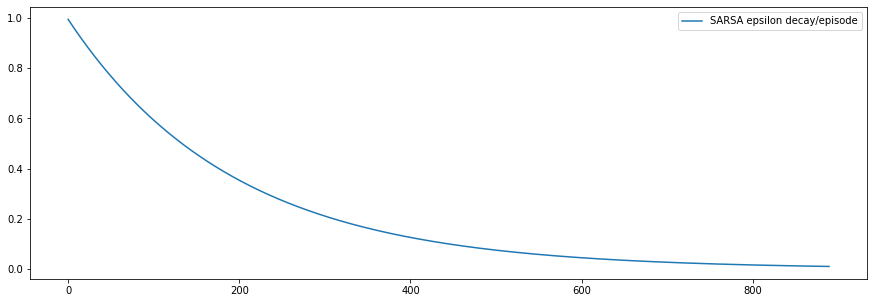

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(epsilon_decay_SARSA, label="SARSA epsilon decay/episode")
plt.legend()
plt.show()

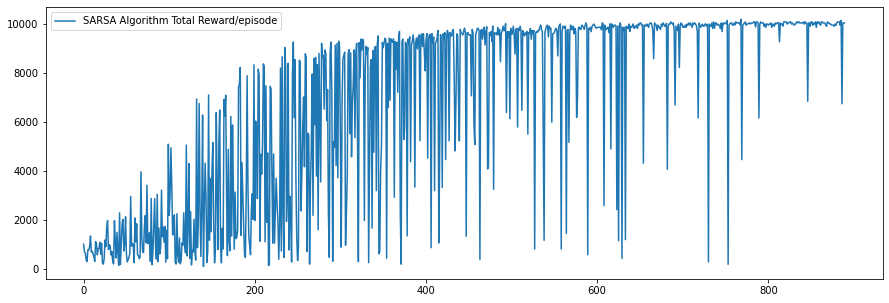

In [ ]:
plt.figure(figsize=(15,5))
plt.plot(reward_per_episode_SARSA, label="SARSA Algorithm Total Reward/episode")
plt.legend()
plt.show()

# References

## 1.  https://medium.com/@filip.knyszewski/model-free-reinforcement-learning-ef0a3945dabb
## 2. https://stackoverflow.com/questions/41141498/how-can-get-sarsa-code-for-gridworld-model-in-r-program
## 3. https://github.com/georgeyiasemis/SARSA-and-Q-learning-on-a-Windy-Grid-World/blob/main/methods.py
## 4. https://medium.com/swlh/introduction-to-reinforcement-learning-coding-sarsa-part-4-2d64d6e37617
## 5. https://piazza.com/class_profile/get_resource/kyxwxncdc4281/l2b121547jg42m
## 6. https://www.youtube.com/watch?v=2-OljVM15gc&ab_channel=%E8%8E%AB%E7%83%A6Python
## 7. https://towardsdatascience.com/reinforcement-learning-temporal-difference-sarsa-q-learning-expected-sarsa-on-python-9fecfda7467e
## 8. https://towardsdatascience.com/intro-to-reinforcement-learning-temporal-difference-learning-sarsa-vs-q-learning-8b4184bb4978
## 9. https://www.geeksforgeeks.org/sarsa-reinforcement-learning/